In [24]:

import sys
import os
import pandas as pd
import numpy as np

# Add the absolute path to the scripts folder
scripts_path = os.path.abspath("../scripts")
sys.path.append(scripts_path)


from data_prep import get_column_types
from utils import (
    plot_numerical_histograms,
    analyze_categorical_features,
    plot_correlation_heatmap,
    plot_conversion_by_category,
    compute_conversion_rate
)

df = pd.read_csv(r'C:\Users\DELL\OneDrive\Data Science\Bank_Telemarketing_Prediction_EDSB25_1\data\interim\processed_data.csv', sep=';')


In [25]:
df = pd.read_csv(r'C:\Users\DELL\OneDrive\Data Science\Bank_Telemarketing_Prediction_EDSB25_1\data\raw\bank-additional-full.csv', sep=';')

In [26]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [28]:
df.describe()  

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [29]:
duplicates= df.duplicated().sum()
x = np.int64(duplicates)
print(int(x))

12


In [4]:
df["y"] = df["y"].map({"yes": 1, "no": 0})


In [5]:

numerical_cols, categorical_cols = get_column_types(df)   

Visualizing feature distributions to detect skewness, outliers, and transformation needs

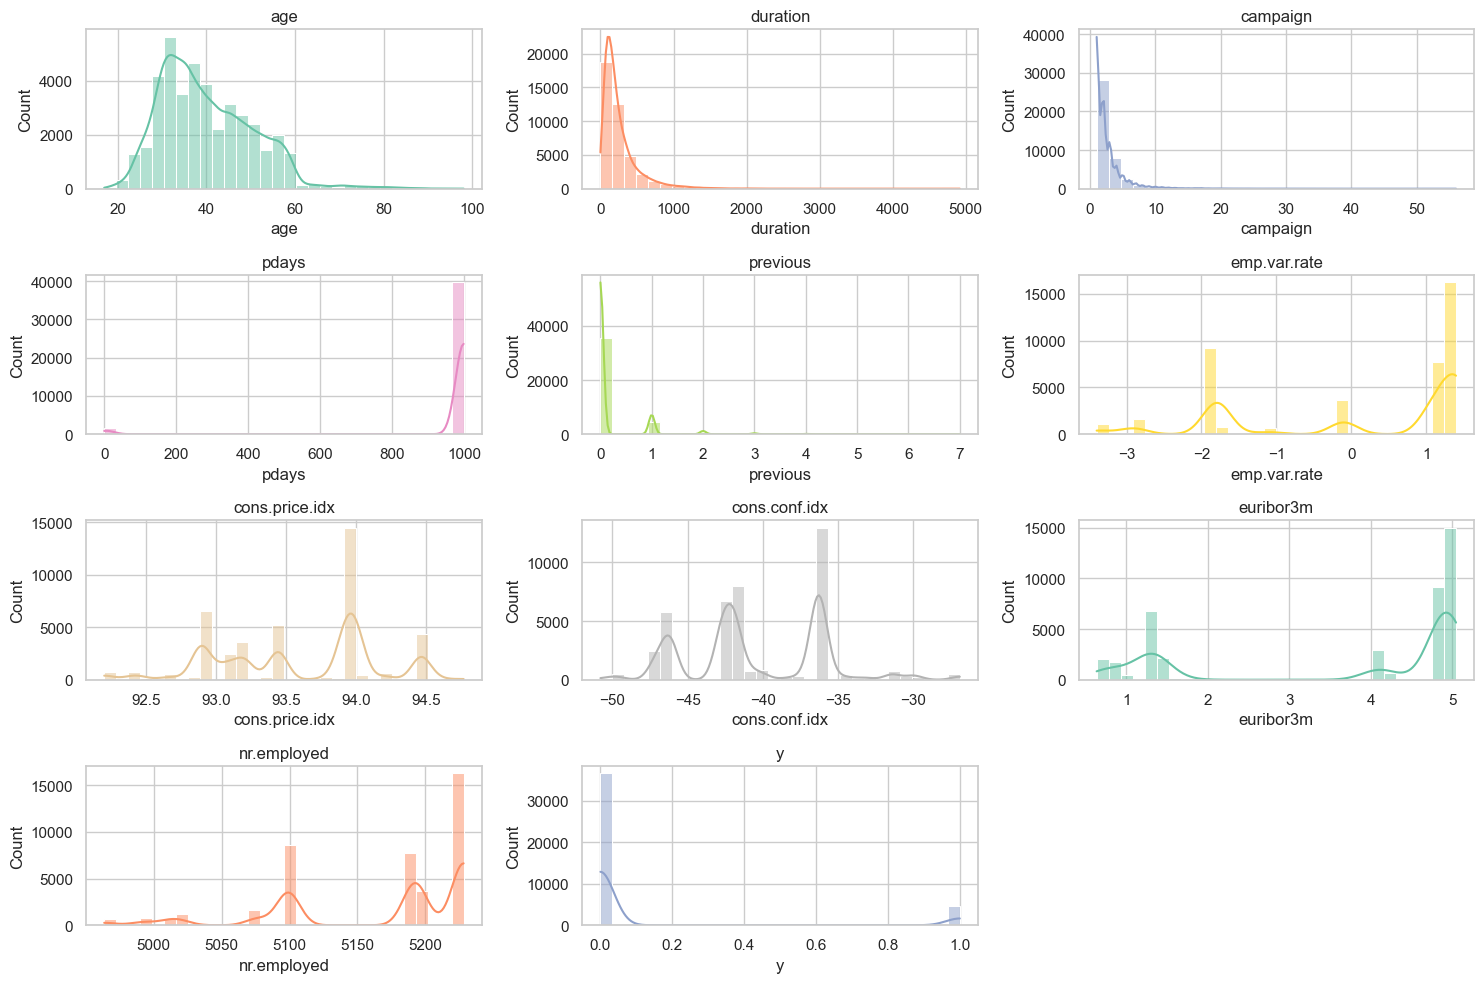

In [6]:
plot_numerical_histograms(df, numerical_cols)

Reviewing category frequencies to assess imbalance and encoding strategy


Value counts for categorical features:

Column: job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64


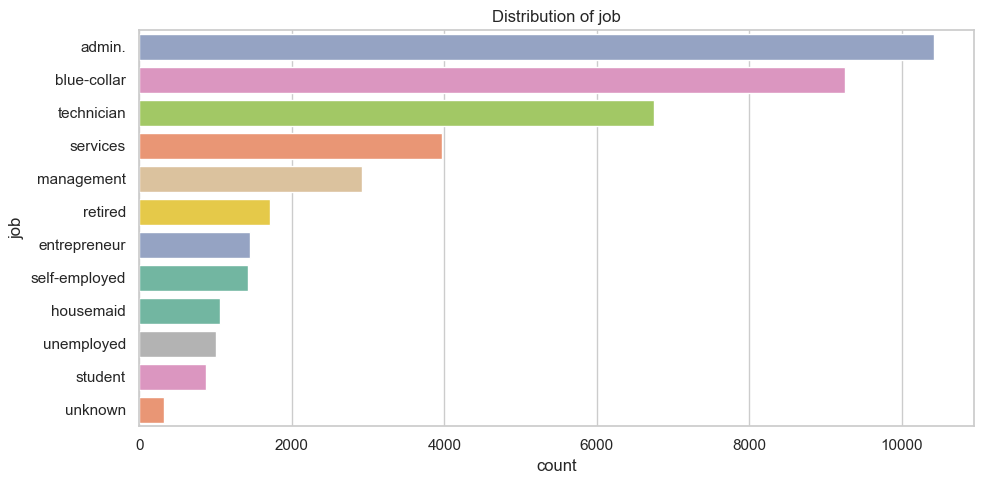


Column: marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64


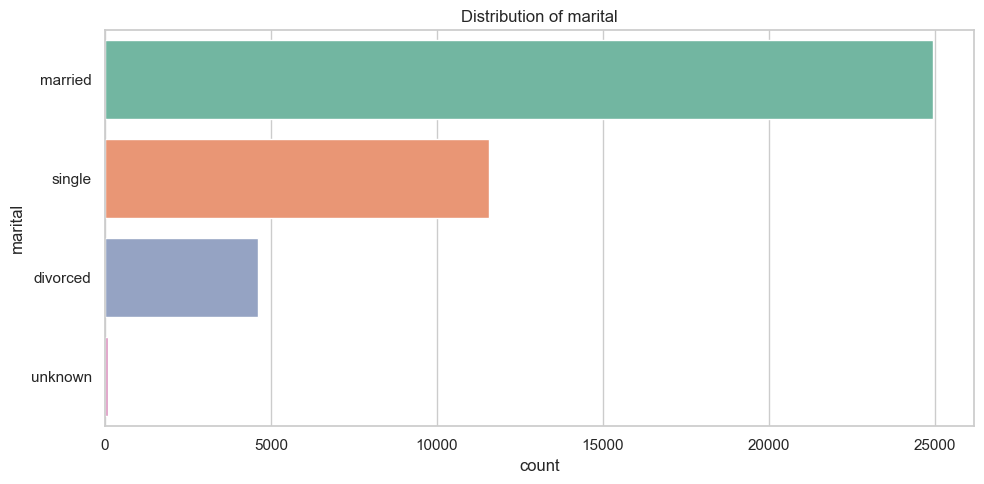


Column: education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64


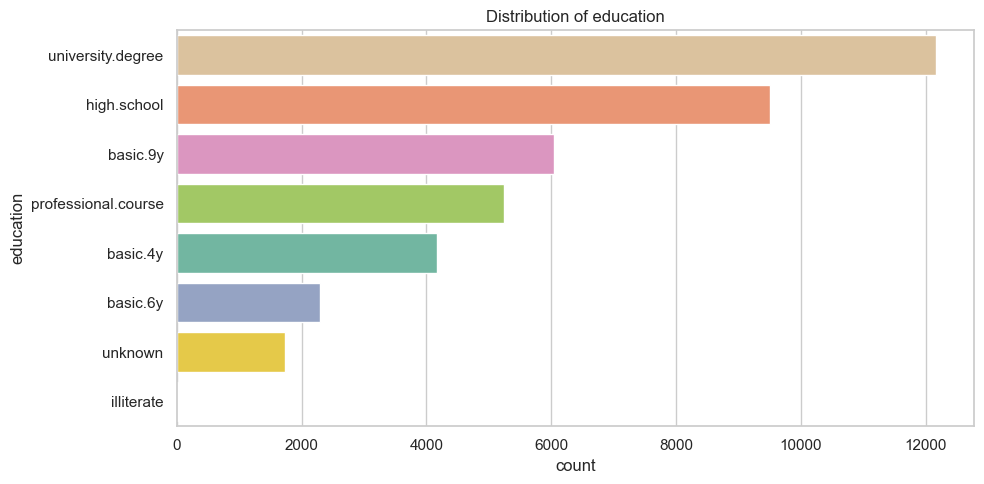


Column: default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64


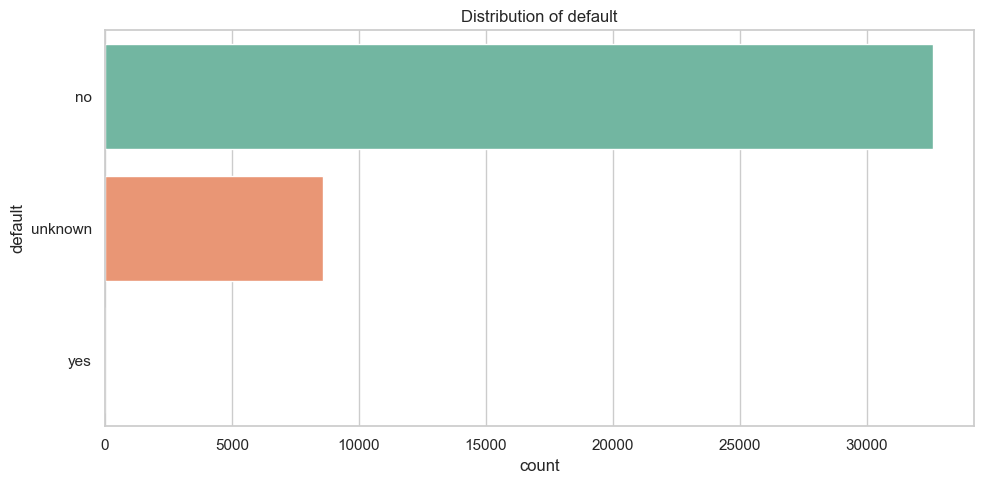


Column: housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64


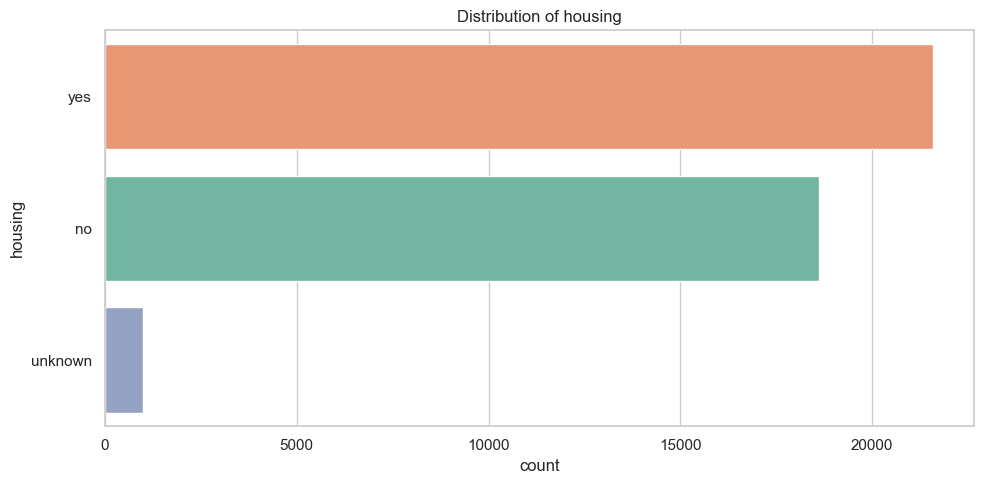


Column: loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64


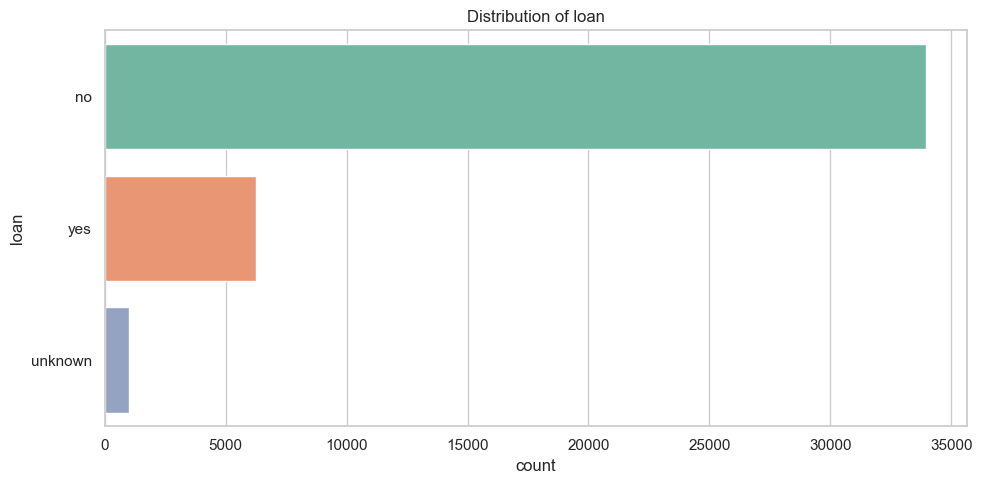


Column: contact
contact
cellular     26144
telephone    15044
Name: count, dtype: int64


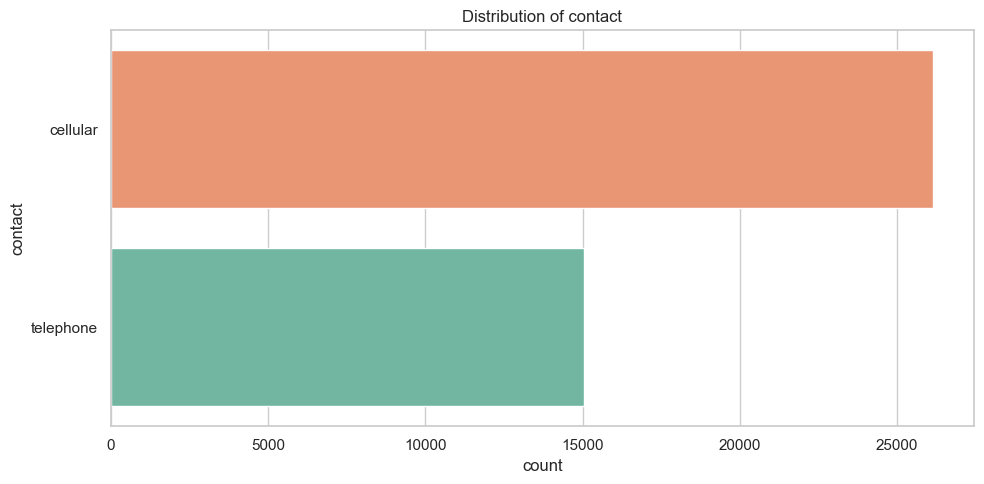


Column: month
month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: count, dtype: int64


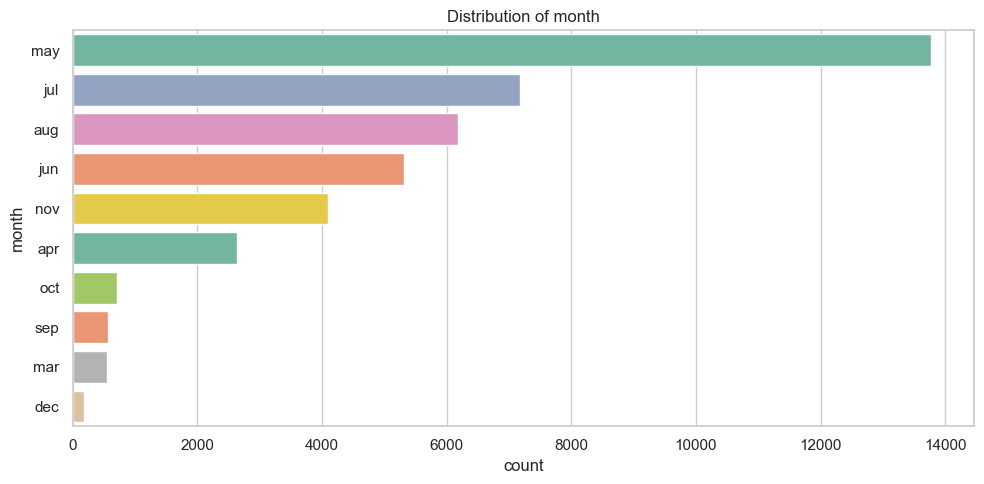


Column: day_of_week
day_of_week
thu    8623
mon    8514
wed    8134
tue    8090
fri    7827
Name: count, dtype: int64


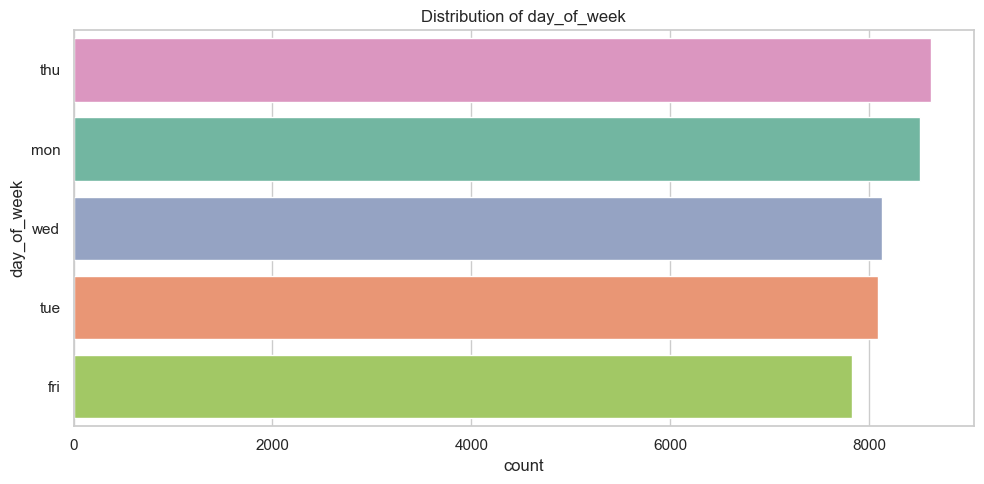


Column: poutcome
poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64


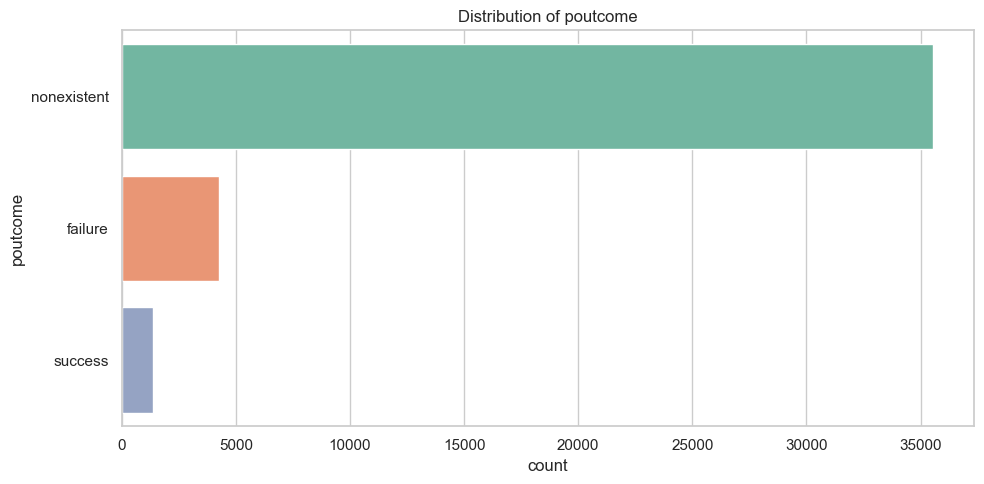

In [7]:
analyze_categorical_features(df, categorical_cols)

Highlighting relationships between features and target to guide feature selection

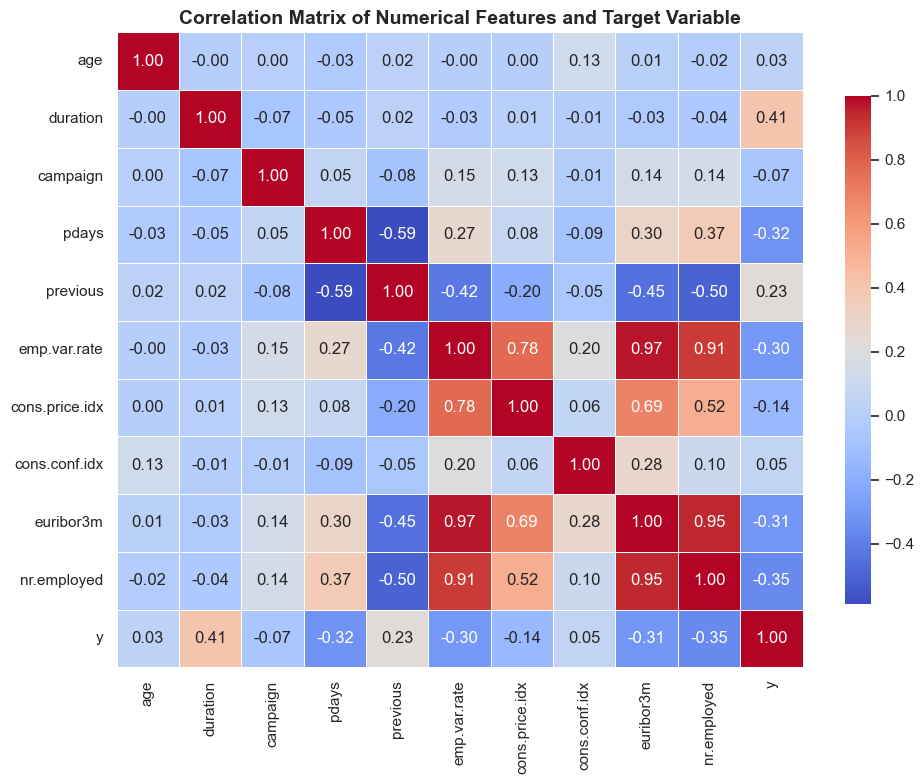

In [8]:
corr_matrix = df[numerical_cols].corr()

plot_correlation_heatmap(
    corr_matrix,
    figsize=(10, 8),
    title="Correlation Matrix of Numerical Features and Target Variable"
)


Comparing conversion rates across segments to identify high-performing groups

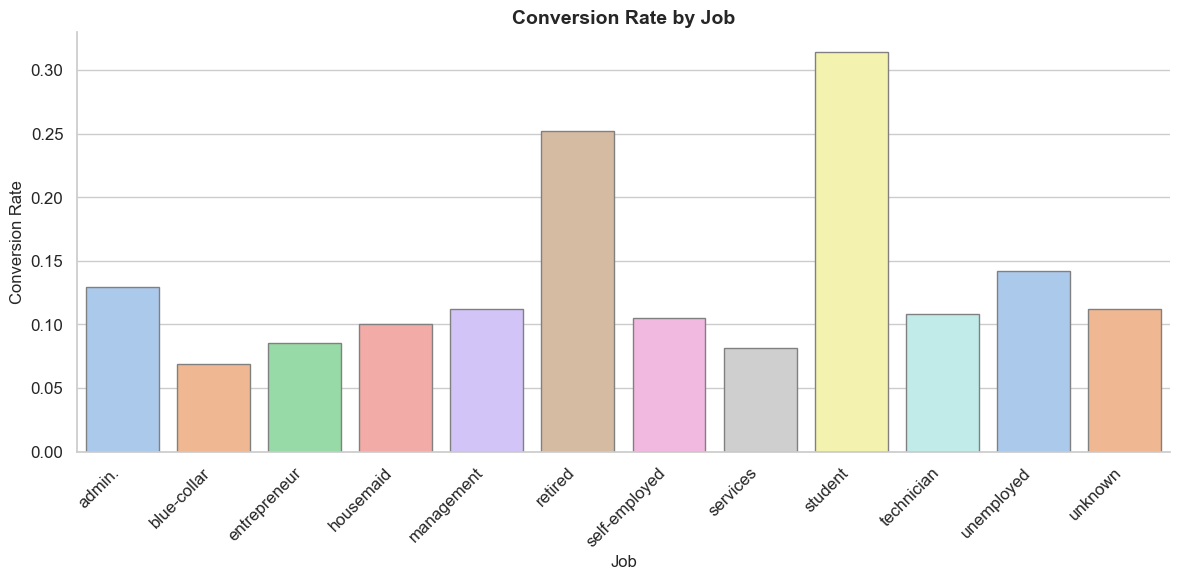

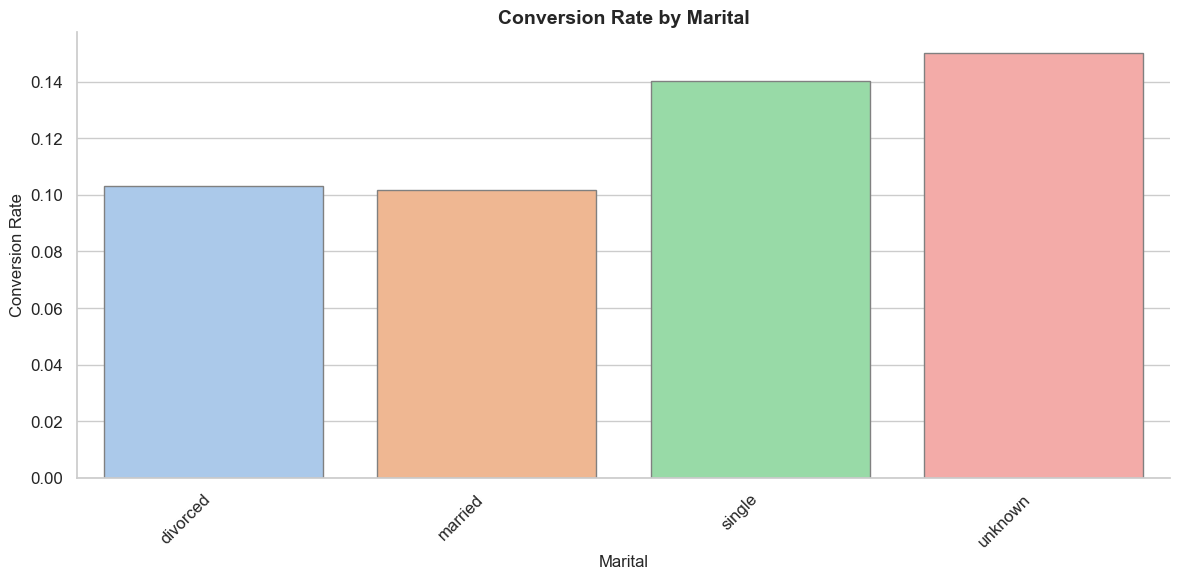

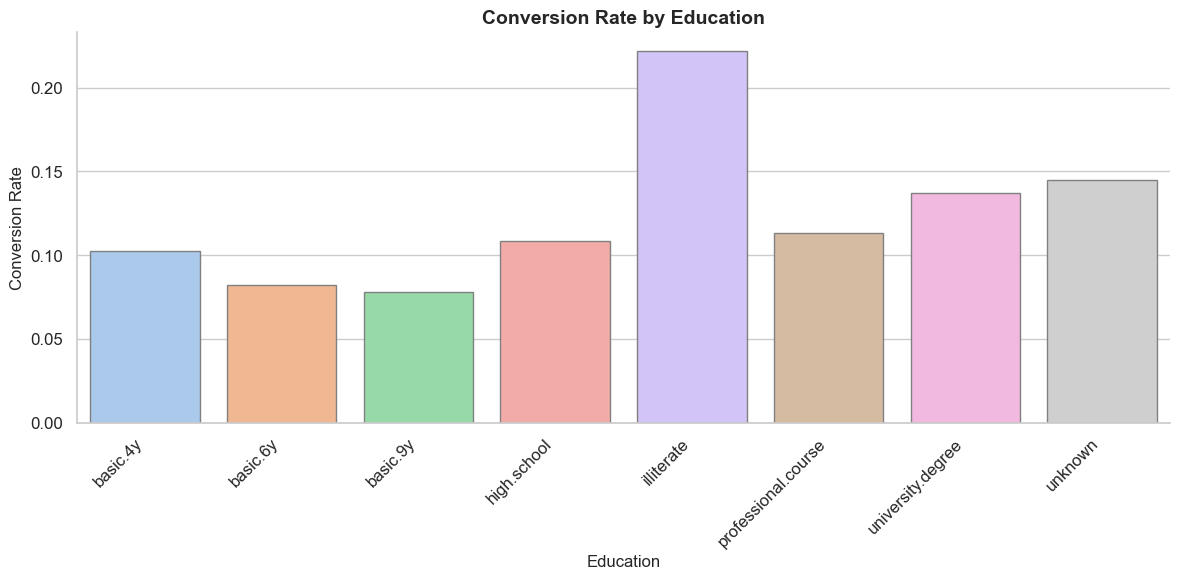

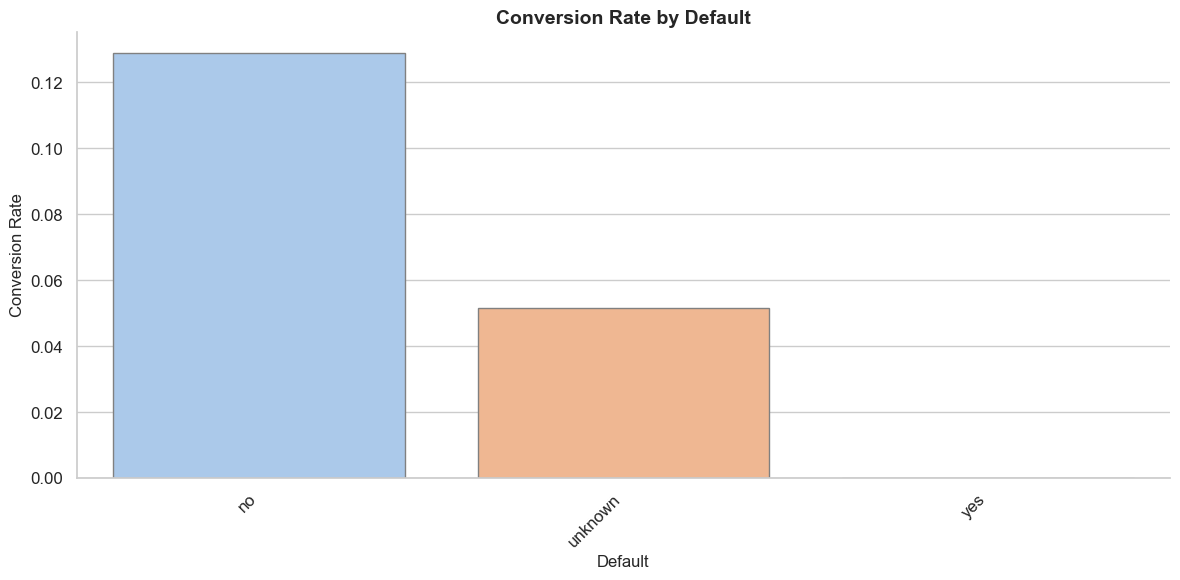

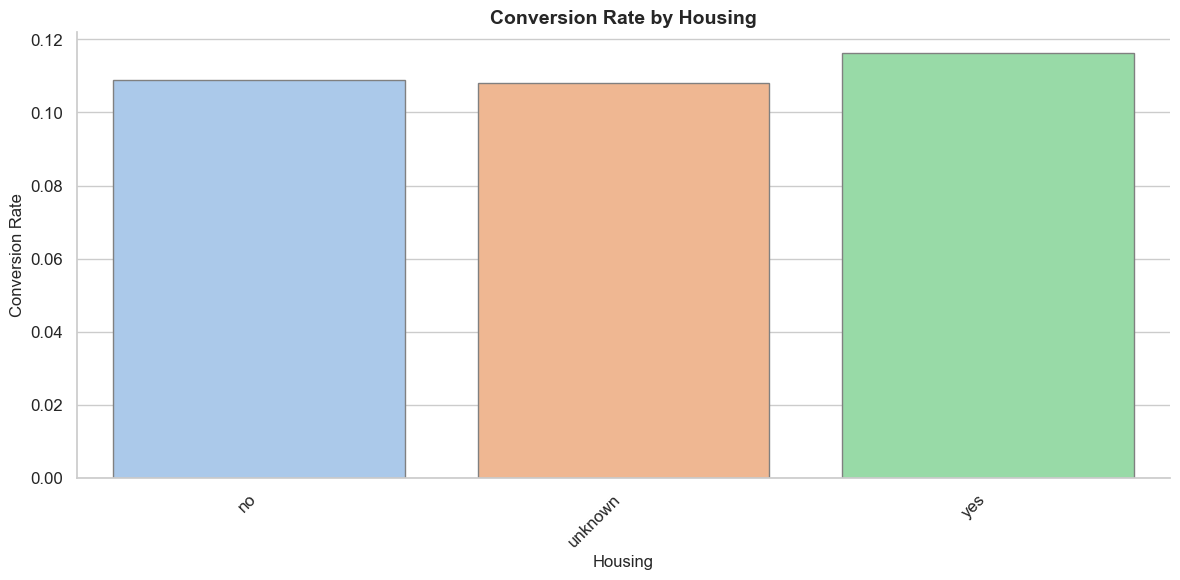

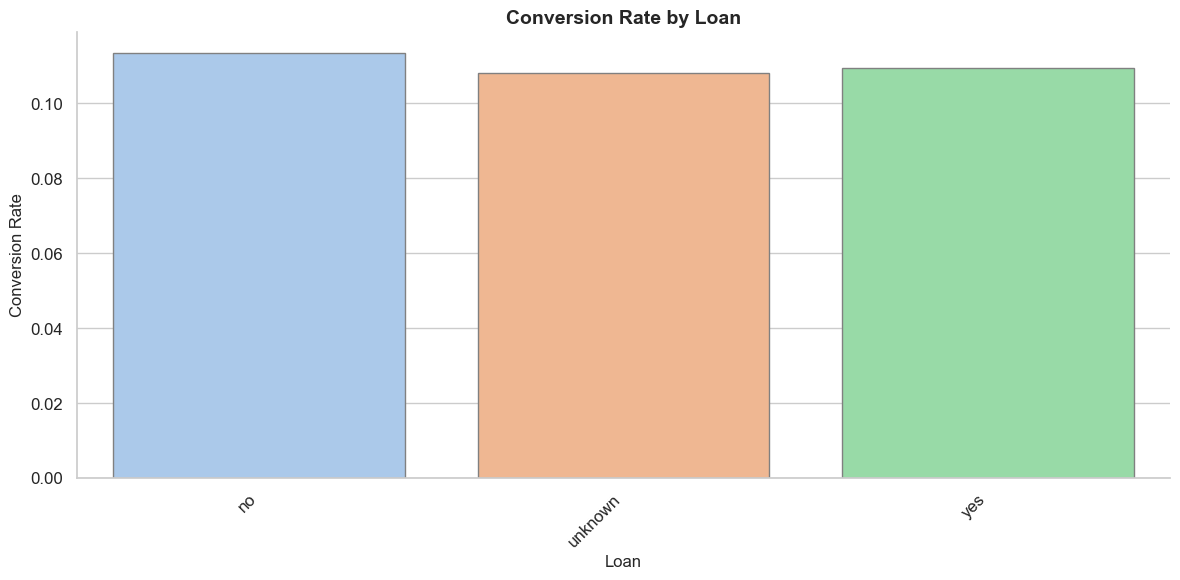

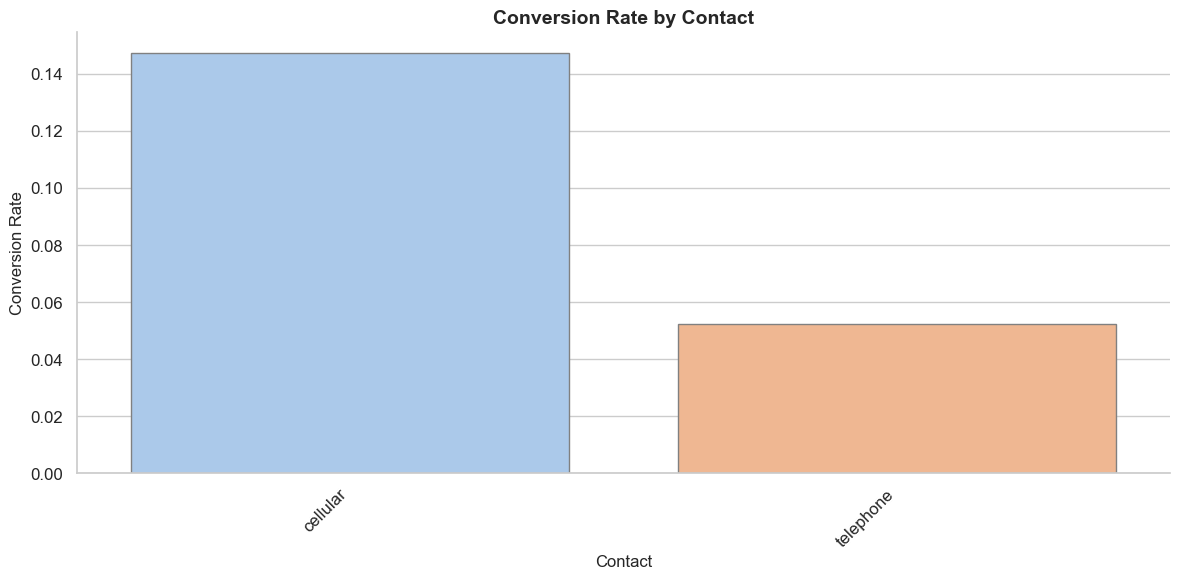

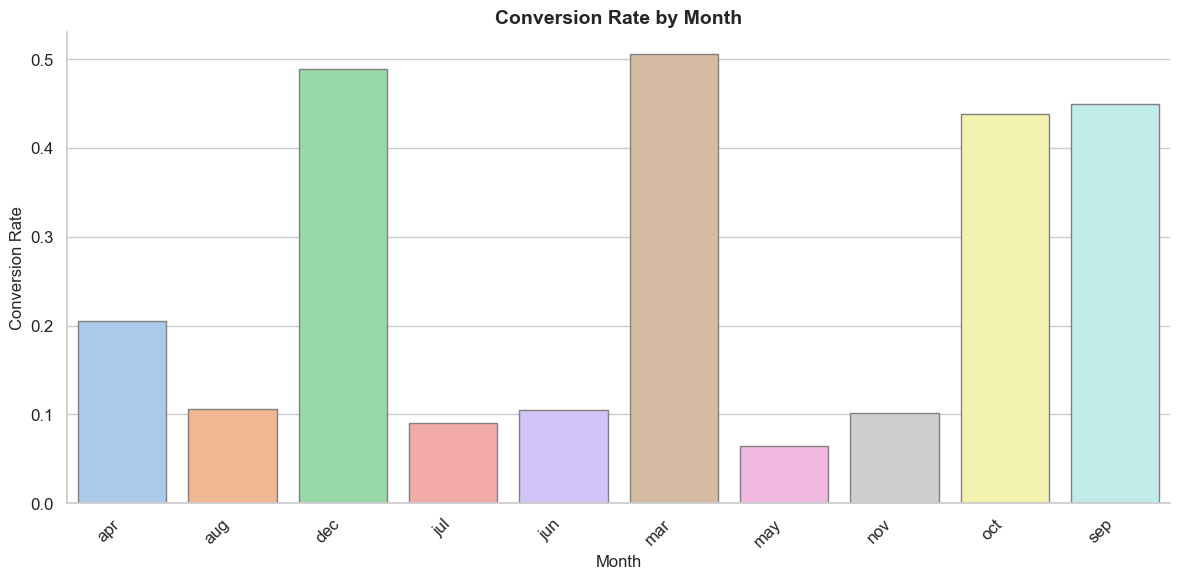

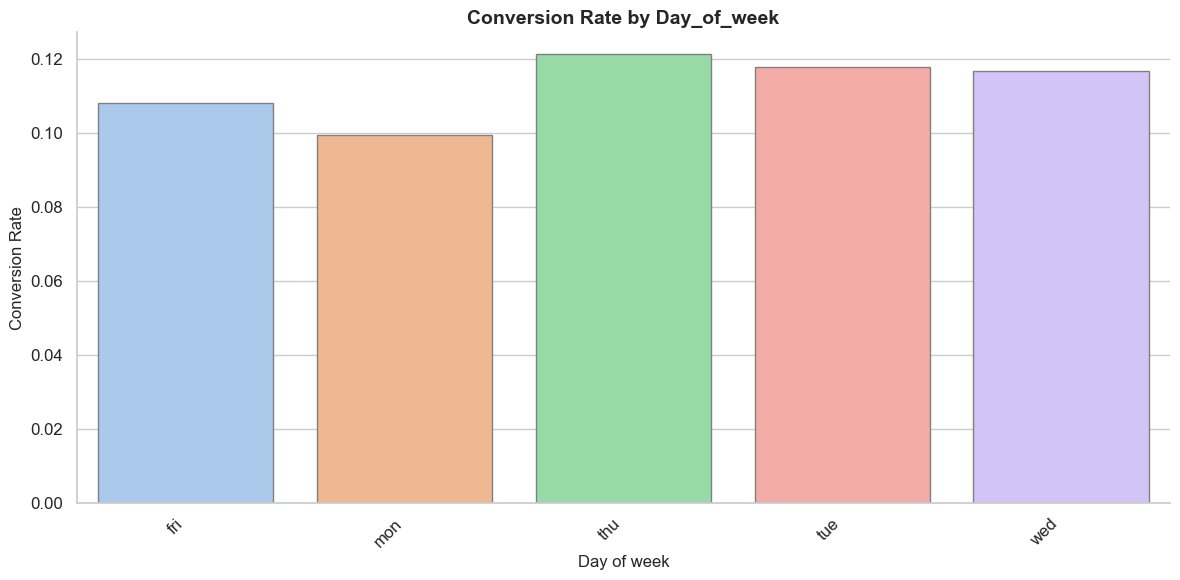

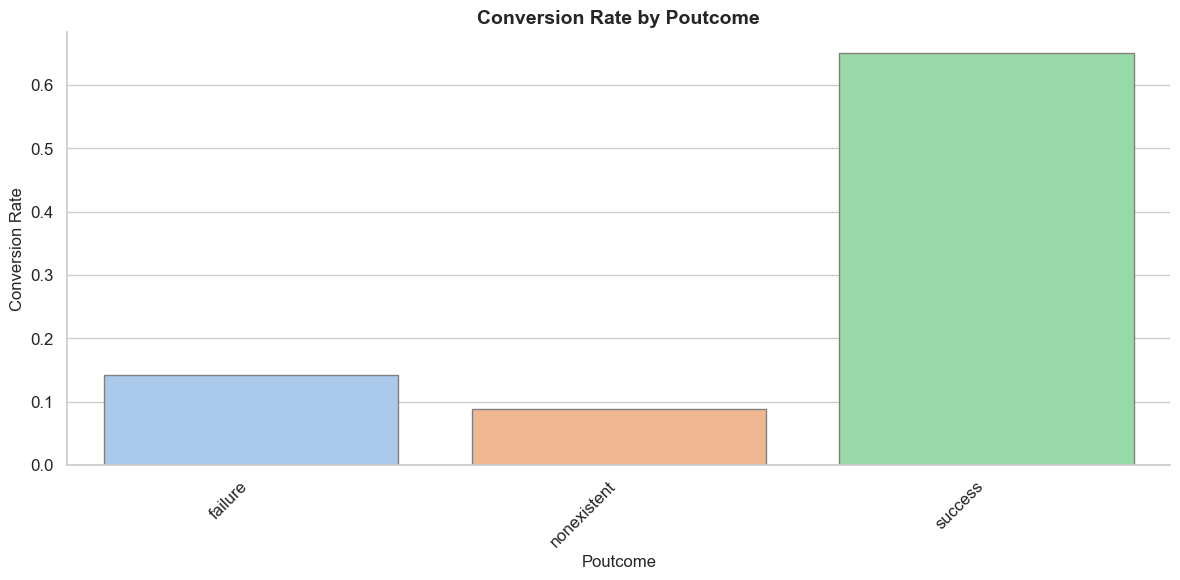

In [9]:
for col in categorical_cols:
    conversion_df = compute_conversion_rate(df, col)
    plot_conversion_by_category(
        conversion_df,
        category_col=col,
        title=f"Conversion Rate by {col.capitalize()}",
        figsize=(12, 6),
        rotation=45,
        palette="pastel"
    )